# Simple Parameter Sensitivity

This notebook changes one behavioral or demand parameter group at a time and plots one chosen relative metric.

Metrics available:

- `utilization`: served slots / total slots
- `avg_wait`: average booking delay in days among booked patients
- `service_rate`: served patients / arrivals

There are no absolute served-patient totals here because the number served scales with `measure_days`. Rates and averages are comparable when the simulation length changes.

For balking and no-show threshold rules, the notebook compares class 1 against class 2 directly:

- class 1 step size vs class 2 step size
- class 1 threshold vs class 2 threshold

For arrival-mix scenarios, total arrival rate is `lambda_total`, class 1 gets `p * lambda_total`, and class 2 gets `(1 - p) * lambda_total`.

The class arrival-rate section varies one class's arrival rate at a time, keeps the other class fixed, and gives two plots per class:

- rate plot: class utilization contribution and class service rate
- wait plot: class average booking delay

In [1]:
from pathlib import Path
from dataclasses import replace
from itertools import product
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_DIR = Path.cwd().resolve()
if not (REPO_DIR / "config_loader.py").exists():
    REPO_DIR = REPO_DIR.parent.resolve()
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from config_loader import load_config
from engine import ClinicAppointmentSimulation
from model import ThresholdRule

plt.style.use("default")

In [2]:
base_config = load_config(REPO_DIR / "configs" / "baseline.yaml")

# Change this between "avg_wait", "service_rate" or "utilization" to plot different metrics
METRIC = "avg_wait"

STEPS = np.linspace(0, 1, 12)                  # step size values: 0.0, 0.2, ..., 1.0
THRESHOLDS = range(base_config.horizon_days) # step moment in days
CANCEL_PROBS = np.linspace(0, 0.30, 14)        # cancellation probabilities

BASE_LAMBDA_TOTAL = sum(params.lambda_per_day for params in base_config.classes.values())
ARRIVAL_RATE_MULTIPLIERS = np.linspace(0.5, 1.5, 12)
CLASS_1_SHARES = np.linspace(0.1, 0.9, 18)

SEED = 123

## Metric Code

In [3]:
def run_metrics(config, seed=SEED):
    config = replace(config, seed=seed)
    results = ClinicAppointmentSimulation(config).run()

    booked = sum(m.booked for m in results.class_metrics.values())
    served = sum(m.served for m in results.class_metrics.values())
    booking_delay = sum(m.total_booking_delay for m in results.class_metrics.values())
    arrivals = sum(m.arrivals for m in results.class_metrics.values())

    return {
        "utilization": results.slot_metrics.served_slots / results.total_slots,
        "avg_wait": booking_delay / booked if booked else 0,
        "service_rate": served / arrivals if arrivals else 0,
    }

base_metrics = pd.DataFrame([run_metrics(base_config)])
display(base_metrics)

,utilization,avg_wait,service_rate
0,0.842209,8.326898,0.270125


## Small Helpers To Change Parameters

In [4]:
def make_step_rule(old_rule, threshold=None, step=None):
    threshold = old_rule.threshold if threshold is None else int(threshold)
    low = old_rule.low
    step = old_rule.high - old_rule.low if step is None else float(step)
    return ThresholdRule(threshold=threshold, low=low, high=min(low + step, 1.0))


def update_classes(config, changes):
    classes = {}
    for class_id, params in config.classes.items():
        classes[class_id] = replace(params, **changes.get(class_id, {}))
    return replace(config, classes=classes)


def set_balking(config, class_steps=None, class_thresholds=None):
    class_steps = class_steps or {}
    class_thresholds = class_thresholds or {}
    changes = {}
    for class_id, params in config.classes.items():
        changes[class_id] = {
            "balk_prob": make_step_rule(
                params.balk_prob,
                threshold=class_thresholds.get(class_id),
                step=class_steps.get(class_id),
            )
        }
    return update_classes(config, changes)


def set_no_show(config, class_steps=None, class_thresholds=None):
    class_steps = class_steps or {}
    class_thresholds = class_thresholds or {}
    changes = {}
    for class_id, params in config.classes.items():
        changes[class_id] = {
            "no_show_prob": make_step_rule(
                params.no_show_prob,
                threshold=class_thresholds.get(class_id),
                step=class_steps.get(class_id),
            )
        }
    return update_classes(config, changes)


def set_cancellation(config, class_probs):
    changes = {class_id: {"cancel_prob": prob} for class_id, prob in class_probs.items()}
    return update_classes(config, changes)


def set_arrival_mix(config, lambda_total, class_1_share):
    class_1_share = float(class_1_share)
    lambda_total = float(lambda_total)
    return update_classes(
        config,
        {
            1: {"lambda_per_day": class_1_share * lambda_total},
            2: {"lambda_per_day": (1 - class_1_share) * lambda_total},
        },
    )


def set_arrival_multiplier(config, multiplier):
    lambda_total = BASE_LAMBDA_TOTAL * float(multiplier)
    base_class_1_share = config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL
    return set_arrival_mix(config, lambda_total, base_class_1_share)


def set_class_arrival_rate(config, class_id, lambda_per_day):
    return update_classes(config, {class_id: {"lambda_per_day": float(lambda_per_day)}})


def run_class_metrics(config, seed=SEED):
    config = replace(config, seed=seed)
    results = ClinicAppointmentSimulation(config).run()

    rows = []
    for class_id, metrics in results.class_metrics.items():
        rows.append({
            "class_id": class_id,
            "lambda_per_day": config.classes[class_id].lambda_per_day,
            "class_utilization": metrics.served / results.total_slots,
            "class_service_rate": metrics.served / metrics.arrivals if metrics.arrivals else 0,
            "class_avg_wait": metrics.mean_booking_delay,
        })
    return pd.DataFrame(rows)

In [5]:
def heatmap(df, x, y, value=METRIC, title=None):
    table = df.pivot(index=y, columns=x, values=value).sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(table.values, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(title or value)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([f"{v:.2f}" if isinstance(v, float) else v for v in table.columns])
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([f"{v:.2f}" if isinstance(v, float) else v for v in table.index])
    fig.colorbar(image, ax=ax, label=value)
    plt.show()

    return table

## 1. Balking Step Size By Class

Everything stays at baseline except the balking step size for class 1 and class 2.

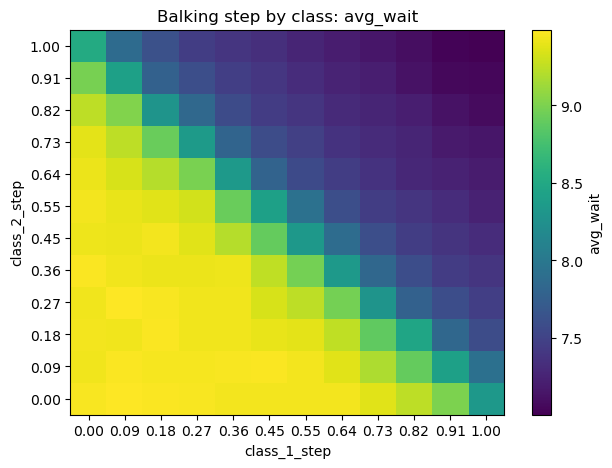

class_1_step,0.000000,0.090909,0.181818,0.272727,0.363636,0.454545,0.545455,0.636364,0.727273,0.818182,0.909091,1.000000
class_2_step,,,,,,,,,,,,
0.000000,9.460183,9.488698,9.469767,9.460437,9.441420,9.448898,9.442360,9.444540,9.380692,9.245261,8.999233,8.333121
0.090909,9.439863,9.470433,9.455772,9.455130,9.461144,9.469558,9.447635,9.376847,9.185401,8.900008,8.419789,7.923758
0.181818,9.449800,9.435567,9.477681,9.439967,9.439222,9.407007,9.388077,9.247694,8.882432,8.466588,7.836235,7.581403
0.272727,9.436570,9.481301,9.460690,9.432338,9.438302,9.334874,9.242122,8.972017,8.286694,7.781652,7.591659,7.464160
0.363636,9.472699,9.438944,9.420202,9.418460,9.423368,9.255215,8.969668,8.348476,7.836804,7.594497,7.442258,7.384916
0.454545,9.428233,9.414032,9.447188,9.375456,9.215909,8.901320,8.331925,7.882737,7.598088,7.455361,7.376316,7.322181
0.545455,9.441687,9.409190,9.377224,9.318132,8.917089,8.416755,7.929681,7.603507,7.459390,7.390290,7.318884,7.244366
0.636364,9.411450,9.334285,9.209767,8.993315,8.345495,7.799697,7.562577,7.457522,7.373716,7.281447,7.247272,7.191850
0.727273,9.387980,9.238780,8.920641,8.357954,7.802611,7.587582,7.478716,7.366213,7.311220,7.266809,7.184198,7.155058


In [6]:
rows = []
for class_1_step, class_2_step in product(STEPS, STEPS):
    config = set_balking(base_config, class_steps={1: class_1_step, 2: class_2_step})
    rows.append({
        "class_1_step": class_1_step,
        "class_2_step": class_2_step,
        **run_metrics(config),
    })

balk_class_df = pd.DataFrame(rows)
heatmap(balk_class_df, "class_1_step", "class_2_step", title=f"Balking step by class: {METRIC}")

## 2. Balking Threshold By Class

Everything stays at baseline except the balking threshold for class 1 and class 2. Step sizes stay fixed at baseline.

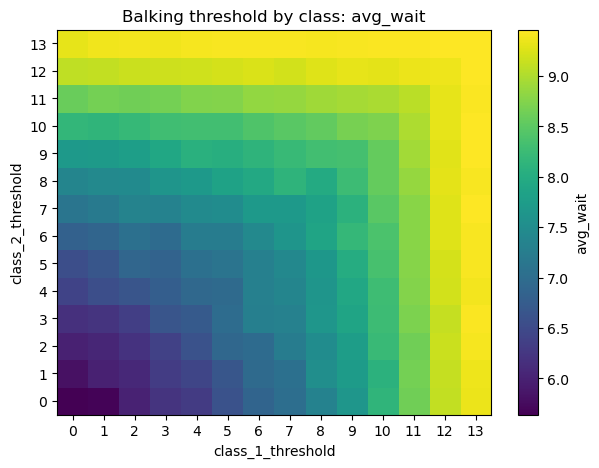

class_1_threshold,0,1,2,3,4,5,6,7,8,9,10,11,12,13
class_2_threshold,,,,,,,,,,,,,,
0,5.641247,5.681475,6.009120,6.209529,6.299051,6.600405,6.878788,7.018513,7.335321,7.651587,8.137759,8.631897,9.105356,9.355560
1,5.817615,5.997798,6.086191,6.321849,6.433305,6.669799,6.954219,7.057991,7.527873,7.741531,8.090622,8.661292,9.125994,9.368938
2,5.998280,6.054420,6.193715,6.379450,6.605786,6.911545,6.975252,7.252005,7.494612,7.766839,8.225651,8.634239,9.153091,9.411710
3,6.164241,6.217752,6.348651,6.643631,6.726906,6.989691,7.289675,7.326205,7.646628,7.867049,8.255026,8.704787,9.131866,9.440313
4,6.416566,6.562559,6.650639,6.776387,6.931107,6.963354,7.310330,7.372421,7.640208,7.927748,8.273779,8.749824,9.202218,9.395678
5,6.553989,6.662727,6.908412,6.860721,7.046960,7.114484,7.309794,7.430888,7.663432,8.010619,8.352524,8.766259,9.212421,9.417665
6,6.823495,6.880647,7.052903,6.983099,7.242541,7.246453,7.437691,7.638735,7.865053,8.180013,8.374387,8.785700,9.273170,9.422622
7,7.132180,7.204429,7.348049,7.329132,7.471849,7.495991,7.700880,7.698070,7.847884,8.097229,8.483890,8.785890,9.281007,9.454599
8,7.377166,7.445149,7.474831,7.638949,7.712340,7.838888,7.942637,8.129606,7.976465,8.257714,8.553536,8.863012,9.297387,9.417579


In [7]:
rows = []
for class_1_threshold, class_2_threshold in product(THRESHOLDS, THRESHOLDS):
    config = set_balking(
        base_config,
        class_thresholds={1: class_1_threshold, 2: class_2_threshold},
    )
    rows.append({
        "class_1_threshold": class_1_threshold,
        "class_2_threshold": class_2_threshold,
        **run_metrics(config),
    })

balk_threshold_df = pd.DataFrame(rows)
heatmap(
    balk_threshold_df,
    "class_1_threshold",
    "class_2_threshold",
    title=f"Balking threshold by class: {METRIC}",
)

## 3. No-Show Step Size By Class

Everything stays at baseline except the no-show step size for class 1 and class 2. Thresholds stay fixed at baseline.

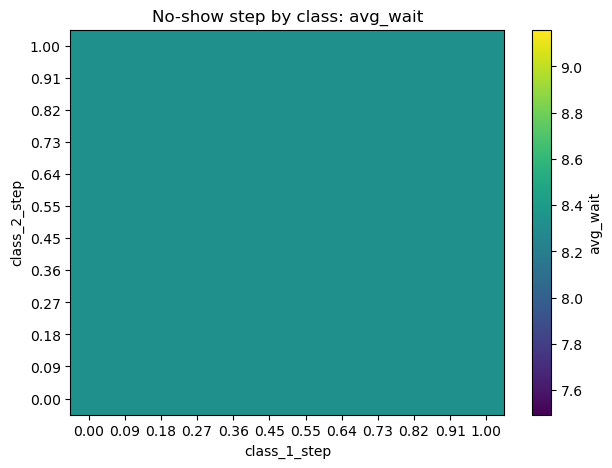

class_1_step,0.000000,0.090909,0.181818,0.272727,0.363636,0.454545,0.545455,0.636364,0.727273,0.818182,0.909091,1.000000
class_2_step,,,,,,,,,,,,
0.000000,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.090909,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.181818,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.272727,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.363636,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.454545,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.545455,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.636364,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
0.727273,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898


In [8]:
rows = []
for class_1_step, class_2_step in product(STEPS, STEPS):
    config = set_no_show(base_config, class_steps={1: class_1_step, 2: class_2_step})
    rows.append({
        "class_1_step": class_1_step,
        "class_2_step": class_2_step,
        **run_metrics(config),
    })

no_show_step_df = pd.DataFrame(rows)
heatmap(
    no_show_step_df,
    "class_1_step",
    "class_2_step",
    title=f"No-show step by class: {METRIC}",
)

## 4. No-Show Threshold By Class

Everything stays at baseline except the no-show threshold for class 1 and class 2. Step sizes stay fixed at baseline.

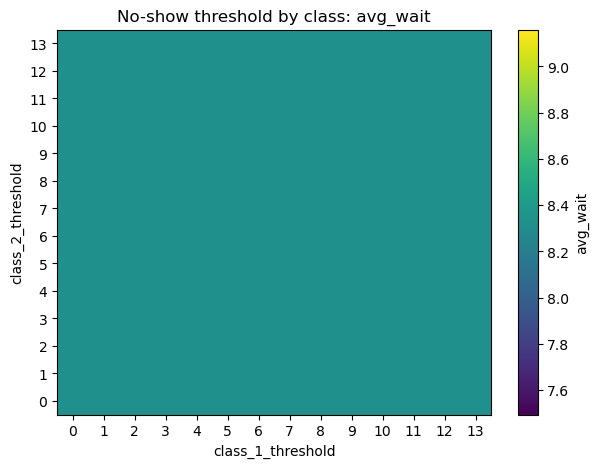

class_1_threshold,0,1,2,3,4,5,6,7,8,9,10,11,12,13
class_2_threshold,,,,,,,,,,,,,,
0,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
1,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
2,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
3,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
4,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
5,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
6,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
7,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898
8,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898,8.326898


In [9]:
rows = []
for class_1_threshold, class_2_threshold in product(THRESHOLDS, THRESHOLDS):
    config = set_no_show(
        base_config,
        class_thresholds={1: class_1_threshold, 2: class_2_threshold},
    )
    rows.append({
        "class_1_threshold": class_1_threshold,
        "class_2_threshold": class_2_threshold,
        **run_metrics(config),
    })

no_show_threshold_df = pd.DataFrame(rows)
heatmap(
    no_show_threshold_df,
    "class_1_threshold",
    "class_2_threshold",
    title=f"No-show threshold by class: {METRIC}",
)

## 5. Cancellation Probability By Class

Cancellation has no threshold in this model, so this varies the daily cancellation probability for each class.

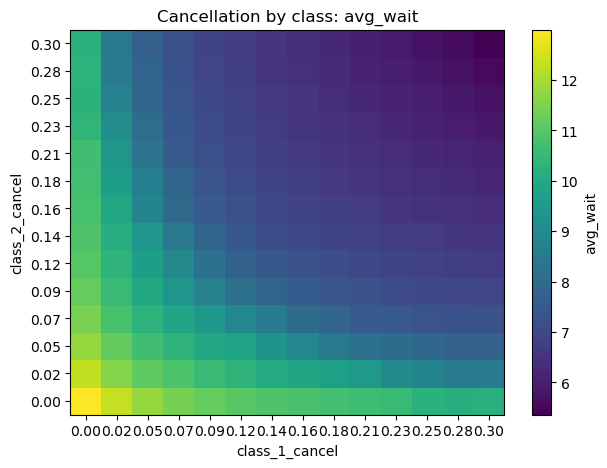

class_1_cancel,0.000000,0.023077,0.046154,0.069231,0.092308,0.115385,0.138462,0.161538,0.184615,0.207692,0.230769,0.253846,0.276923,0.300000
class_2_cancel,,,,,,,,,,,,,,
0.000000,12.999914,12.321287,11.787310,11.423771,11.193504,11.005369,10.888768,10.813235,10.725406,10.636161,10.534730,10.246797,10.166840,10.207601
0.023077,12.302232,11.626490,11.119495,10.836137,10.520972,10.316111,10.065884,9.890358,9.690672,9.459385,8.995329,8.801606,8.469819,8.504266
0.046154,11.783670,11.165659,10.657231,10.332772,9.979820,9.791950,9.256681,8.891975,8.452371,8.212871,8.073817,7.902866,7.721105,7.693991
0.069231,11.462867,10.776886,10.305910,9.885342,9.447533,8.938528,8.479026,8.056393,7.853766,7.575821,7.495460,7.356885,7.279515,7.247159
0.092308,11.182858,10.547807,10.007456,9.358237,8.733400,8.186511,7.779459,7.581241,7.402044,7.254642,7.102188,7.055997,6.978899,6.946389
0.115385,10.972890,10.337072,9.617665,8.965504,8.228339,7.742378,7.468225,7.256823,7.166685,7.014531,6.912243,6.835786,6.776181,6.729865
0.138462,10.866109,10.120823,9.337907,8.417542,7.832929,7.423999,7.207026,7.046525,6.927384,6.848666,6.745774,6.676292,6.572570,6.536921
0.161538,10.776788,9.922631,8.863617,8.009949,7.567751,7.264759,7.028913,6.889392,6.813115,6.674384,6.539058,6.487265,6.416649,6.330142
0.184615,10.696495,9.612407,8.644104,7.858236,7.377491,7.108831,6.914444,6.763339,6.635355,6.525446,6.413085,6.351780,6.271318,6.175462


In [10]:
rows = []
for class_1_cancel, class_2_cancel in product(CANCEL_PROBS, CANCEL_PROBS):
    config = set_cancellation(base_config, {1: class_1_cancel, 2: class_2_cancel})
    rows.append({
        "class_1_cancel": class_1_cancel,
        "class_2_cancel": class_2_cancel,
        **run_metrics(config),
    })

cancel_df = pd.DataFrame(rows)
heatmap(cancel_df, "class_1_cancel", "class_2_cancel", title=f"Cancellation by class: {METRIC}")

## 6. Total Arrival Rate And Class Mix

This varies demand pressure and the class mix together. For each grid point:

- `lambda_total = multiplier * baseline lambda_total`
- `lambda_1 = p * lambda_total`
- `lambda_2 = (1 - p) * lambda_total`

All behavioral rules stay fixed at baseline.

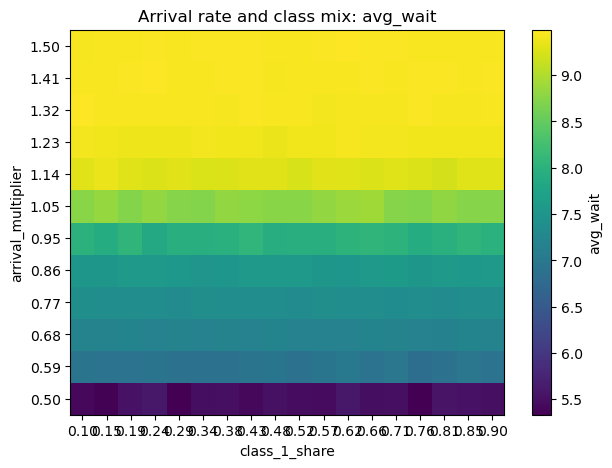

class_1_share,0.100000,0.147059,0.194118,0.241176,0.288235,0.335294,0.382353,0.429412,0.476471,0.523529,0.570588,0.617647,0.664706,0.711765,0.758824,0.805882,0.852941,0.900000
arrival_multiplier,,,,,,,,,,,,,,,,,,
0.500000,5.418978,5.355072,5.541510,5.605753,5.349096,5.495407,5.501011,5.415233,5.519250,5.476536,5.462560,5.605508,5.493031,5.506423,5.333848,5.550824,5.534050,5.497906
0.590909,6.940752,6.919055,6.924294,6.940913,6.906419,6.898617,6.906339,6.936124,6.942597,6.892489,6.953405,7.022914,6.920803,6.978516,6.831638,6.899270,6.987588,6.923441
0.681818,7.189272,7.194849,7.206985,7.176823,7.195630,7.178037,7.199059,7.185095,7.216980,7.177019,7.184432,7.181278,7.211045,7.186135,7.175906,7.158181,7.205086,7.197079
0.772727,7.403593,7.375541,7.379411,7.368306,7.335227,7.383598,7.371302,7.371903,7.371389,7.339080,7.381491,7.375398,7.378214,7.360887,7.371594,7.344839,7.371145,7.364658
0.863636,7.536189,7.537864,7.574520,7.575693,7.548796,7.507705,7.521848,7.574350,7.572377,7.560729,7.531369,7.519729,7.575884,7.605166,7.541290,7.583720,7.551658,7.571604
0.954545,8.013140,7.904513,8.052926,7.847894,7.933424,7.956877,7.974489,8.076890,7.926455,7.960502,7.954669,8.025125,8.051031,8.017150,7.903184,7.969262,8.057210,7.997453
1.045455,8.754117,8.842419,8.720549,8.826183,8.734036,8.725293,8.821130,8.789984,8.761100,8.748739,8.815675,8.867527,8.895376,8.729103,8.719385,8.799177,8.738716,8.741856
1.136364,9.310721,9.377475,9.291535,9.265412,9.302584,9.257389,9.275259,9.303868,9.302672,9.245969,9.303196,9.295276,9.278482,9.294036,9.272799,9.225717,9.281237,9.291890
1.227273,9.423439,9.403880,9.392369,9.384797,9.383191,9.426406,9.409916,9.409885,9.373207,9.401472,9.408658,9.434847,9.426460,9.415122,9.396893,9.398810,9.407324,9.402663


In [11]:
rows = []
for multiplier, class_1_share in product(ARRIVAL_RATE_MULTIPLIERS, CLASS_1_SHARES):
    lambda_total = BASE_LAMBDA_TOTAL * multiplier
    config = set_arrival_mix(base_config, lambda_total, class_1_share)
    rows.append({
        "arrival_multiplier": multiplier,
        "class_1_share": class_1_share,
        "lambda_total": lambda_total,
        "lambda_1": class_1_share * lambda_total,
        "lambda_2": (1 - class_1_share) * lambda_total,
        **run_metrics(config),
    })

demand_mix_df = pd.DataFrame(rows)
heatmap(
    demand_mix_df,
    "class_1_share",
    "arrival_multiplier",
    title=f"Arrival rate and class mix: {METRIC}",
)

## 7. Class Arrival Rate Sweeps

These plots vary one class's arrival rate at a time and keep the other class fixed at baseline.

For each class there are two plots against that class's arrival rate:

- class utilization contribution and class service rate
- class average booking delay

In [12]:
rows = []
for target_class in sorted(base_config.classes):
    base_lambda = base_config.classes[target_class].lambda_per_day
    for multiplier in ARRIVAL_RATE_MULTIPLIERS:
        class_lambda = base_lambda * multiplier
        config = set_class_arrival_rate(base_config, target_class, class_lambda)
        class_metrics = run_class_metrics(config)
        row = class_metrics.loc[class_metrics["class_id"].eq(target_class)].iloc[0].to_dict()
        rows.append({
            "target_class": target_class,
            "arrival_multiplier": multiplier,
            "target_lambda": class_lambda,
            **row,
        })

class_arrival_df = pd.DataFrame(rows)
display(class_arrival_df.head())

,target_class,arrival_multiplier,target_lambda,class_id,lambda_per_day,class_utilization,class_service_rate,class_avg_wait
0,1,0.500000,25.000000,1.0,25.000000,0.278168,0.363952,7.258179
1,1,0.590909,29.545455,1.0,29.545455,0.313442,0.336334,7.415838
2,1,0.681818,34.090909,1.0,34.090909,0.343065,0.320048,7.498542
3,1,0.772727,38.636364,1.0,38.636364,0.360360,0.303570,7.598098
4,1,0.863636,43.181818,1.0,43.181818,0.383647,0.282161,7.908685


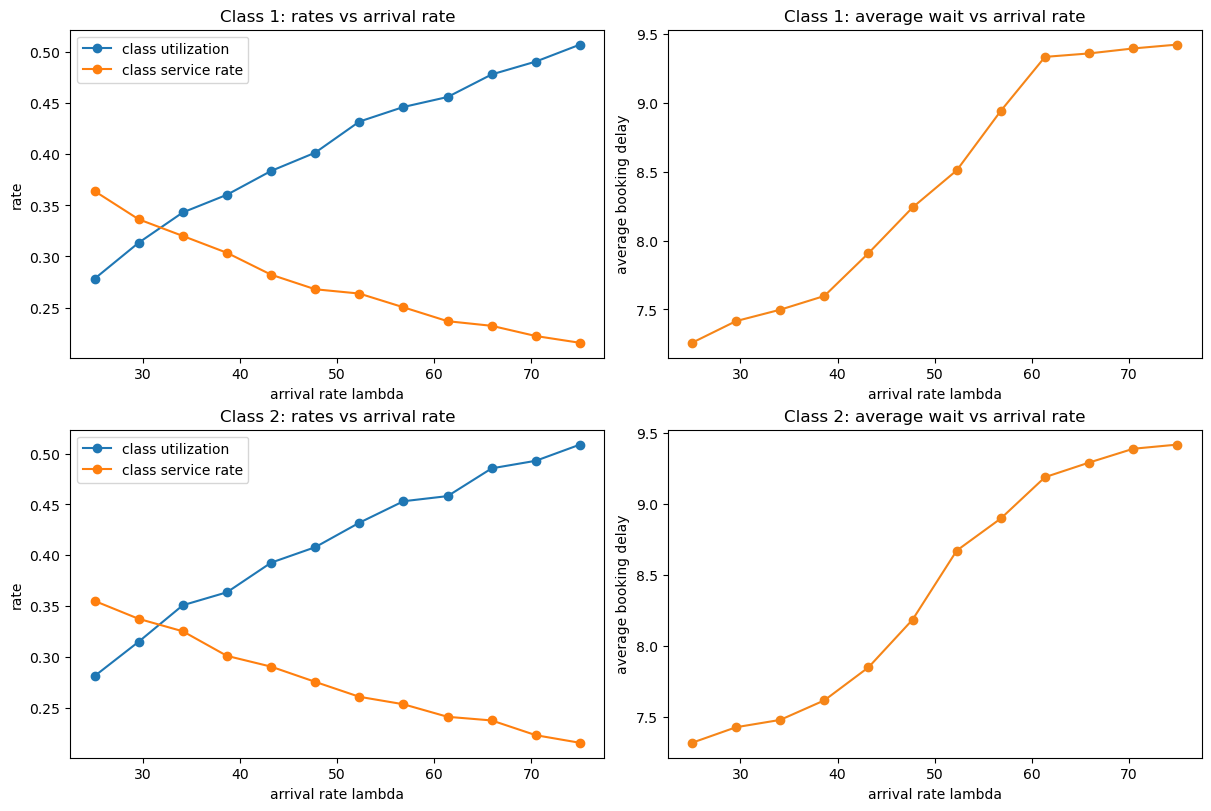

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for row_idx, target_class in enumerate(sorted(base_config.classes)):
    data = class_arrival_df.loc[class_arrival_df["target_class"].eq(target_class)].sort_values("target_lambda")

    rate_ax = axes[row_idx, 0]
    rate_ax.plot(data["target_lambda"], data["class_utilization"], marker="o", label="class utilization")
    rate_ax.plot(data["target_lambda"], data["class_service_rate"], marker="o", label="class service rate")
    rate_ax.set_title(f"Class {target_class}: rates vs arrival rate")
    rate_ax.set_xlabel("arrival rate lambda")
    rate_ax.set_ylabel("rate")
    rate_ax.legend()

    wait_ax = axes[row_idx, 1]
    wait_ax.plot(data["target_lambda"], data["class_avg_wait"], marker="o", color="#F58518")
    wait_ax.set_title(f"Class {target_class}: average wait vs arrival rate")
    wait_ax.set_xlabel("arrival rate lambda")
    wait_ax.set_ylabel("average booking delay")

plt.show()

## 8. Named Demand Scenarios

These are a few readable scenarios around the baseline. They are useful when you want a compact table rather than a full grid.

,scenario,arrival_multiplier,class_1_share,lambda_1,lambda_2,utilization,avg_wait,service_rate
1,low demand,0.75,0.50,37.50,37.50,0.844349,7.314383,0.359621
0,baseline,1.00,0.50,50.00,50.00,0.842209,8.326898,0.270125
4,class 2 heavy,1.00,0.25,25.00,75.00,0.835017,8.389154,0.267512
3,class 1 heavy,1.00,0.75,75.00,25.00,0.838271,8.394368,0.268090
6,"high demand, class 2 heavy",1.25,0.25,31.25,93.75,0.834503,9.429945,0.212060
5,"high demand, class 1 heavy",1.25,0.75,93.75,31.25,0.835873,9.430709,0.212210
2,high demand,1.25,0.50,62.50,62.50,0.843750,9.438092,0.215628


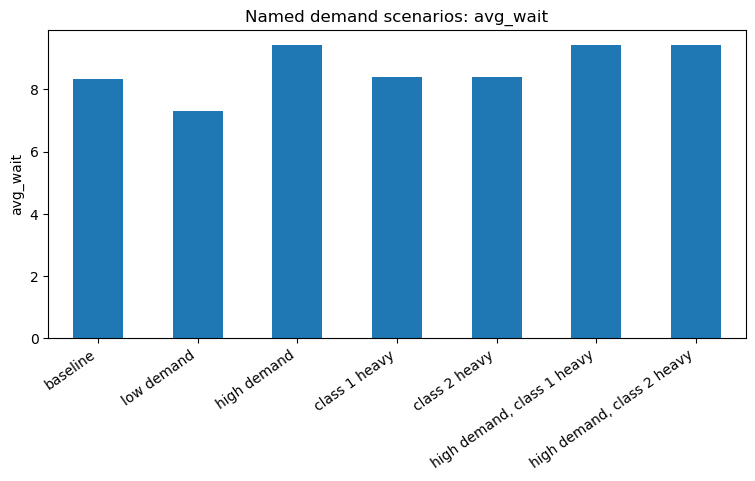

In [14]:
named_scenarios = [
    ("baseline", 1.00, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("low demand", 0.75, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("high demand", 1.25, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("class 1 heavy", 1.00, 0.75),
    ("class 2 heavy", 1.00, 0.25),
    ("high demand, class 1 heavy", 1.25, 0.75),
    ("high demand, class 2 heavy", 1.25, 0.25),
]

rows = []
for name, multiplier, class_1_share in named_scenarios:
    lambda_total = BASE_LAMBDA_TOTAL * multiplier
    config = set_arrival_mix(base_config, lambda_total, class_1_share)
    rows.append({
        "scenario": name,
        "arrival_multiplier": multiplier,
        "class_1_share": class_1_share,
        "lambda_1": class_1_share * lambda_total,
        "lambda_2": (1 - class_1_share) * lambda_total,
        **run_metrics(config),
    })

named_demand_df = pd.DataFrame(rows)
display(named_demand_df.sort_values(METRIC, ascending=(METRIC == "avg_wait")))

fig, ax = plt.subplots(figsize=(9, 4))
named_demand_df.plot(kind="bar", x="scenario", y=METRIC, ax=ax, legend=False)
ax.set_title(f"Named demand scenarios: {METRIC}")
ax.set_xlabel("")
ax.set_ylabel(METRIC)
plt.xticks(rotation=35, ha="right")
plt.show()

## Best Tested Settings

In [15]:
def best_rows(df, n=5):
    # For avg_wait lower is better. For utilization and service_rate higher is better.
    ascending = METRIC == "avg_wait"
    return df.sort_values(METRIC, ascending=ascending).head(n)

print("Balking step sweep")
display(best_rows(balk_class_df))

print("Balking threshold sweep")
display(best_rows(balk_threshold_df))

print("No-show step sweep")
display(best_rows(no_show_step_df))

print("No-show threshold sweep")
display(best_rows(no_show_threshold_df))

print("Cancellation sweep")
display(best_rows(cancel_df))

print("Arrival rate and class-mix sweep")
display(best_rows(demand_mix_df))

print("Named demand scenarios")
display(best_rows(named_demand_df))

print("Class arrival-rate sweeps")
display(class_arrival_df.sort_values(["target_class", "target_lambda"]))

Balking step sweep


,class_1_step,class_2_step,utilization,avg_wait,service_rate
143,1.000000,1.000000,0.841353,7.005810,0.267236
131,0.909091,1.000000,0.842637,7.031904,0.270447
142,1.000000,0.909091,0.839640,7.044608,0.270831
130,0.909091,0.909091,0.841182,7.062724,0.267624
141,1.000000,0.818182,0.847089,7.081902,0.268662


Balking threshold sweep


,class_1_threshold,class_2_threshold,utilization,avg_wait,service_rate
0,0,0,0.889555,5.641247,0.282031
14,1,0,0.876113,5.681475,0.280177
1,0,1,0.881079,5.817615,0.279652
15,1,1,0.855993,5.997798,0.270365
2,0,2,0.856678,5.998280,0.273997


No-show step sweep


...

,arrival_multiplier,class_1_share,lambda_total,lambda_1,lambda_2,utilization,avg_wait,service_rate
14,0.5,0.758824,50.0,37.941176,12.058824,0.919007,5.333848,0.592110
4,0.5,0.288235,50.0,14.411765,35.588235,0.923288,5.349096,0.596482
1,0.5,0.147059,50.0,7.352941,42.647059,0.926884,5.355072,0.597383
7,0.5,0.429412,50.0,21.470588,28.529412,0.915753,5.415233,0.589014
0,0.5,0.100000,50.0,5.000000,45.000000,0.918322,5.418978,0.590159


Named demand scenarios


,scenario,arrival_multiplier,class_1_share,lambda_1,lambda_2,utilization,avg_wait,service_rate
1,low demand,0.75,0.50,37.50,37.50,0.844349,7.314383,0.359621
0,baseline,1.00,0.50,50.00,50.00,0.842209,8.326898,0.270125
4,class 2 heavy,1.00,0.25,25.00,75.00,0.835017,8.389154,0.267512
3,class 1 heavy,1.00,0.75,75.00,25.00,0.838271,8.394368,0.268090
6,"high demand, class 2 heavy",1.25,0.25,31.25,93.75,0.834503,9.429945,0.212060


Class arrival-rate sweeps


,target_class,arrival_multiplier,target_lambda,class_id,lambda_per_day,class_utilization,class_service_rate,class_avg_wait
0,1,0.500000,25.000000,1.0,25.000000,0.278168,0.363952,7.258179
1,1,0.590909,29.545455,1.0,29.545455,0.313442,0.336334,7.415838
2,1,0.681818,34.090909,1.0,34.090909,0.343065,0.320048,7.498542
3,1,0.772727,38.636364,1.0,38.636364,0.360360,0.303570,7.598098
4,1,0.863636,43.181818,1.0,43.181818,0.383647,0.282161,7.908685
5,1,0.954545,47.727273,1.0,47.727273,0.401541,0.267893,8.240869
6,1,1.045455,52.272727,1.0,52.272727,0.431935,0.263694,8.509867
7,1,1.136364,56.818182,1.0,56.818182,0.446233,0.250252,8.942306
8,1,1.227273,61.363636,1.0,61.363636,0.455993,0.236659,9.333645
9,1,1.318182,65.909091,1.0,65.909091,0.478082,0.232135,9.358752
